<a href="https://colab.research.google.com/github/jessiepsx/classificacao-score-credito/blob/main/Classifica%C3%A7%C3%A3o_Score_Cr%C3%A9dito_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Leitura e Exploração Inicial dos Dados





In [1]:
#importando o dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-score-classification' dataset.
Path to dataset files: /kaggle/input/credit-score-classification


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# carregar os dados
df = pd.read_csv(os.path.join(path, 'train.csv'))

# ver o que tem dentro
print(df.shape)
print(df.info())
display(df.head())

/tmp/ipykernel_3411/472933953.py:8: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'train.csv'))


(100000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


##Limpeza e Preparação dos Dados

In [16]:
def limpar_e_converter(df, colunas):
    for col in colunas:
        if df[col].dtype == 'object':

            #transforma em string, remove espaços e o caractere '_'
            df[col] = df[col].astype(str).str.replace('_', '', regex=False).str.strip()

            #transforma strings vazias ou com erros em NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

#colunas que vêm travadas como texto
colunas_para_limpar = [
    'Age', 'Annual_Income', 'Outstanding_Debt',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit'
]

df = limpar_e_converter(df, colunas_para_limpar)

print(limpar_e_converter(df, colunas_para_limpar).info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         98665 non-null   float64
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [17]:
# Idades absurdas viram nulo (NaN)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# Contas bancárias negativas ou maiores que 20 viram nulo (NaN)
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan

# Parcelas (EMI) negativas viram zero (já que não existe parcela negativa)
df.loc[df['Total_EMI_per_month'] < 0, 'Total_EMI_per_month'] = 0


In [18]:
# calculamos as medianas de cada coluna problemática
mediana_idade = df['Age'].median()
mediana_renda = df['Annual_Income'].median()
mediana_divida = df['Outstanding_Debt'].median()
mediana_atrasos = df['Num_of_Delayed_Payment'].median()
mediana_limite = df['Changed_Credit_Limit'].median()
mediana_contas = df['Num_Bank_Accounts'].median()

# substituímos os valores nulos (NaN) pela respectiva mediana
df['Age'] = df['Age'].fillna(mediana_idade)
df['Annual_Income'] = df['Annual_Income'].fillna(mediana_renda)
df['Outstanding_Debt'] = df['Outstanding_Debt'].fillna(mediana_divida)
df['Num_of_Delayed_Payment'] = df['Num_of_Delayed_Payment'].fillna(mediana_atrasos)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].fillna(mediana_limite)
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].fillna(mediana_contas)

In [19]:
colunas_inuteis = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Type_of_Loan']
df_limpo = df.drop(columns=colunas_inuteis)

##Análise Exploratória (EDA)

/tmp/ipykernel_3411/1371470600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpo, x='Credit_Score', order=['Poor', 'Standard', 'Good'], palette='magma')


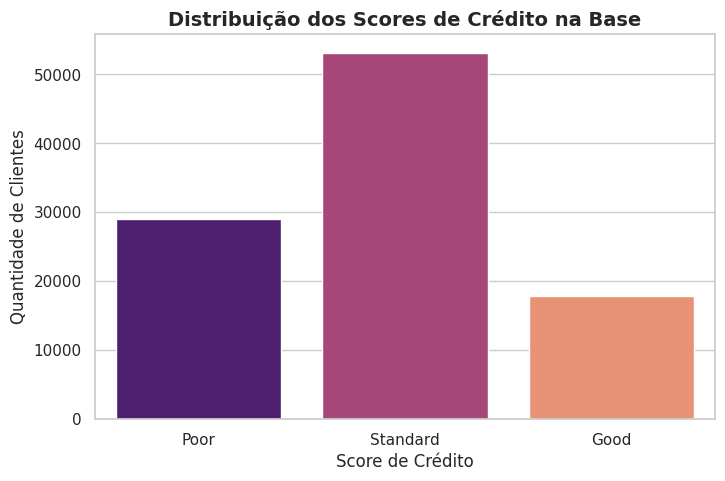

In [20]:
# escolhe o visual de fundo do gráfico (com linhas de grade brancas)
sns.set_theme(style="whitegrid")

# define o tamanho da imagem do gráfico (8 de largura por 5 de altura)
plt.figure(figsize=(8, 5))

# desenha as barras:
# data=df_limpo (usa nossos dados limpos), x='Credit_Score' (coloca as categorias no eixo de baixo),
# order=[...] (força a ordem das barras), palette='magma' (escolhe um conjunto de cores bonito)
sns.countplot(data=df_limpo, x='Credit_Score', order=['Poor', 'Standard', 'Good'], palette='magma')

# adiciona o título principal
plt.title('Distribuição dos Scores de Crédito na Base', fontsize=14, fontweight='bold')

# dá nome para a linha de baixo (Eixo X) e para a linha do lado (Eixo Y)
plt.xlabel('Score de Crédito')
plt.ylabel('Quantidade de Clientes')

#mostra o gráfico
plt.show()

/tmp/ipykernel_3411/3363940349.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='Credit_Score', y='Annual_Income', order=['Poor', 'Standard', 'Good'], palette='viridis')


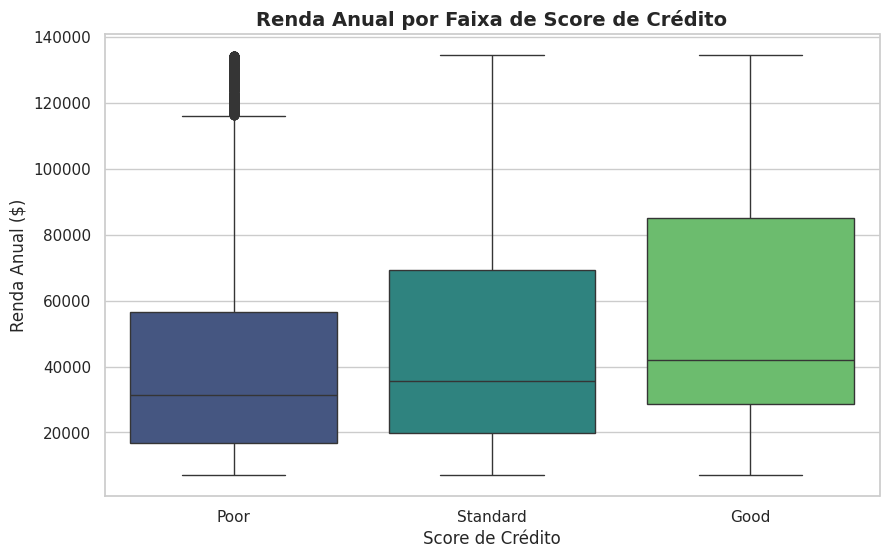

In [21]:
# nova janela para o gráfico com tamanho 10x6
plt.figure(figsize=(10, 6))

# descobre qual é o valor que corta os 5% de pessoas mais ricas (outliers extremos)
# fazemos isso porque se houver um bilionário na base, o gráfico fica achatado e feio
renda_95 = df_limpo['Annual_Income'].quantile(0.95)

# cria uma cópia dos dados apenas com quem ganha menos que esse valor limite
df_filtrado = df_limpo[df_limpo['Annual_Income'] < renda_95]

# desenha as caixinhas cruzando o Score de Crédito (X) com a Renda Anual (Y)
sns.boxplot(data=df_filtrado, x='Credit_Score', y='Annual_Income', order=['Poor', 'Standard', 'Good'], palette='viridis')

# configuração das escritas e os títulos do gráfico
plt.title('Renda Anual por Faixa de Score de Crédito', fontsize=14, fontweight='bold')
plt.xlabel('Score de Crédito')
plt.ylabel('Renda Anual ($)')

plt.show()

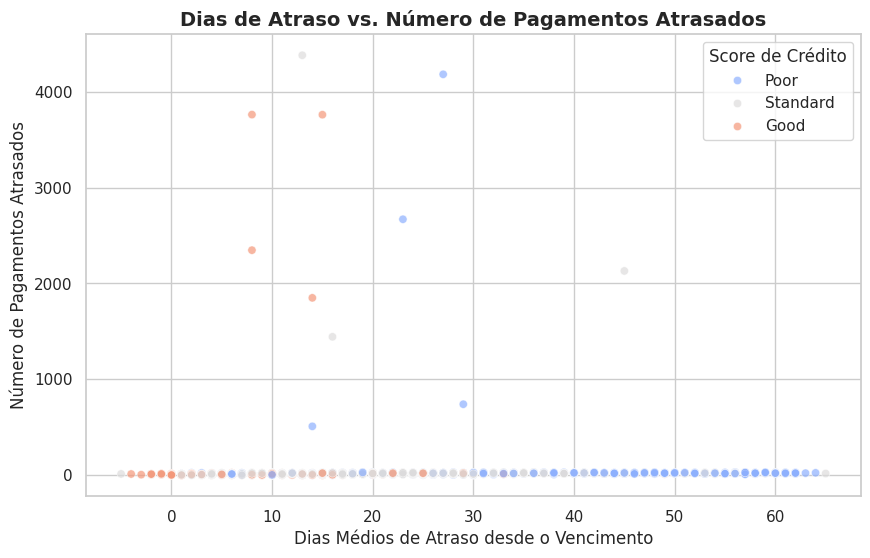

In [11]:
# define o tamanho do gráfico
plt.figure(figsize=(10, 6))

# o dataset original tem milhares de linhas. Se desenharmos todos os pontos,
# o gráfico vira uma mancha gigante e trava o computador.
# O .sample(n=2000) pega 2000 clientes sorteados para representar a base de forma leve.
df_sample = df_limpo.sample(n=2000, random_state=42)

# desenha os pontinhos na tela:
# x e y definem as posições. hue='Credit_Score' define que a cor do ponto depende do score.
# alpha=0.7 deixa os pontos um pouquinho transparentes para conseguirmos ver pontos sobrepostos.
sns.scatterplot(
    data=df_sample,
    x='Delay_from_due_date',
    y='Num_of_Delayed_Payment',
    hue='Credit_Score',
    hue_order=['Poor', 'Standard', 'Good'],
    palette='coolwarm',
    alpha=0.7
)

# adiciona títulos e legendas
plt.title('Dias de Atraso vs. Número de Pagamentos Atrasados', fontsize=14, fontweight='bold')
plt.xlabel('Dias Médios de Atraso desde o Vencimento')
plt.ylabel('Número de Pagamentos Atrasados')
plt.legend(title='Score de Crédito') # cria a caixinha explicando as cores

plt.show()

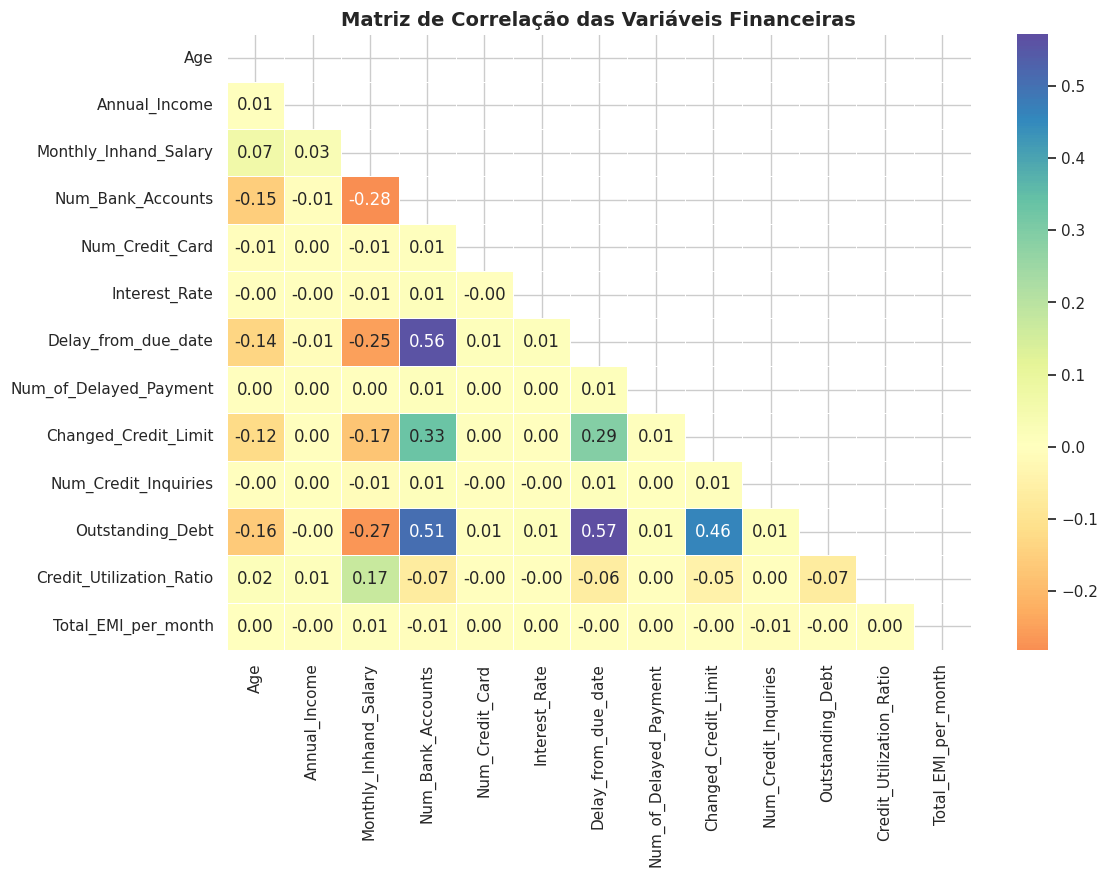

In [12]:
# define um tamanho grande para conseguirmos ler os números perfeitamente
plt.figure(figsize=(12, 8))

# pedimos para o Pandas selecionar apenas as colunas que possuem números
colunas_numericas = df_limpo.select_dtypes(include=['float64', 'int64', 'int32']).columns

# calcula a tabela de correlação matemática entre todas essas colunas
corr = df_limpo[colunas_numericas].corr()

# uma tabela de correlação é espelhada (o lado de cima é igual ao de baixo).
# esse comando cria uma "máscara" para esconder a metade de cima e deixar o visual mais limpo.
mask = np.triu(np.ones_like(corr, dtype=bool))

# desenha o mapa de calor colorindo os quadrados de acordo com o nível de correlação:
# annot=True (escreve o número dentro do quadrado), fmt=".2f" (mostra 2 casas decimais),
# cmap='Spectral' (paleta de cores do vermelho ao azul), linewidths=0.5 (linha separando os quadrados)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Spectral', center=0, linewidths=0.5)

# adiciona o título e exibe
plt.title('Matriz de Correlação das Variáveis Financeiras', fontsize=14, fontweight='bold')
plt.show()

##Modelagem Preditiva

In [22]:
# O 'y' é o que queremos prever: o Score de Crédito
y = df_limpo['Credit_Score']

# O 'X' são todas as outras colunas, exceto o Score de Crédito
X = df_limpo.drop(columns=['Credit_Score'])

In [23]:
from sklearn.preprocessing import LabelEncoder

# criamos o tradutor para a variável alvo (y)
le_alvo = LabelEncoder()
y = le_alvo.fit_transform(y)
# agora y virou um array de números: 0, 1 ou 2

# procuramos colunas de texto em X e traduzimos uma por uma
for coluna in X.columns:
    if X[coluna].dtype == 'object':
        le_coluna = LabelEncoder()
        X[coluna] = le_coluna.fit_transform(X[coluna].astype(str))

In [24]:
from sklearn.model_selection import train_test_split

# dividindo os dados
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,               # recursos numéricos
    y,               # resposta numérica
    test_size=0.20,  # 20% para teste
    random_state=42, # garante que o sorteio seja sempre o mesmo se rodarmos de novo
    stratify=y       # mantém a mesma proporção de Poor/Standard/Good no treino e no teste
)

# tamanho de cada pedaço
print("Dados de Treino (X_treino):", X_treino.shape)
print("Dados de Teste (X_teste):", X_teste.shape)

Dados de Treino (X_treino): (80000, 21)
Dados de Teste (X_teste): (20000, 21)


#####Treinar a Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# criamos o modelo
# random_state=42 serve para o modelo tomar sempre as mesmas decisões se você rodar a célula de novo
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# TREINAMENTO: O modelo estuda a relação entre as variáveis (X) e os resultados (y)
modelo_rf.fit(X_treino, y_treino)
print("Modelo Random Forest treinado com sucesso!")

# PREVISÃO: O modelo chuta as respostas com base no que aprendeu
predicoes_rf = modelo_rf.predict(X_teste)

Modelo Random Forest treinado com sucesso!


--- RELATÓRIO DE PERFORMANCE ---
              precision    recall  f1-score   support

        Poor       0.74      0.72      0.73      3566
    Standard       0.78      0.80      0.79      5799
        Good       0.81      0.80      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.79      0.79      0.79     20000



<Figure size 800x600 with 0 Axes>

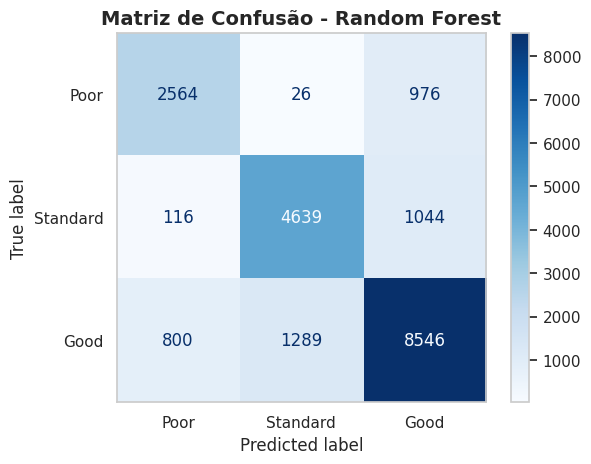

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# relatório de Métricas (Acurácia, Precisão, Recall)
print("--- RELATÓRIO DE PERFORMANCE ---")
print(classification_report(y_teste, predicoes_rf, target_names=['Poor', 'Standard', 'Good']))

# gráfico da Matriz de Confusão (Erros vs. Acertos)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_teste, predicoes_rf)

# desenha o gráfico quadrado mostrando onde o modelo acertou e errou
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Standard', 'Good'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusão - Random Forest', fontsize=14, fontweight='bold')
plt.grid(False) # Remove linhas de grade para o gráfico ficar limpo
plt.show()

#####Treinar o XGBoost

In [29]:
!pip install xgboost
from xgboost import XGBClassifier

# criamos o modelo XGBoost
# random_state=42 para manter o mesmo padrão, e eval_metric='mlogloss' evita avisos de alertas do Python
modelo_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

# TREINAMENTO: O XGBoost estuda os dados de treino
modelo_xgb.fit(X_treino, y_treino)

print("Modelo XGBoost treinado com sucesso!")

# PREVISÃO: O modelo gera os seus palpites de score de crédito
predicoes_xgb = modelo_xgb.predict(X_teste)

Modelo XGBoost treinado com sucesso!


--- RELATÓRIO DE PERFORMANCE (XGBOOST) ---
              precision    recall  f1-score   support

        Poor       0.66      0.69      0.68      3566
    Standard       0.76      0.73      0.74      5799
        Good       0.78      0.78      0.78     10635

    accuracy                           0.75     20000
   macro avg       0.73      0.73      0.73     20000
weighted avg       0.75      0.75      0.75     20000



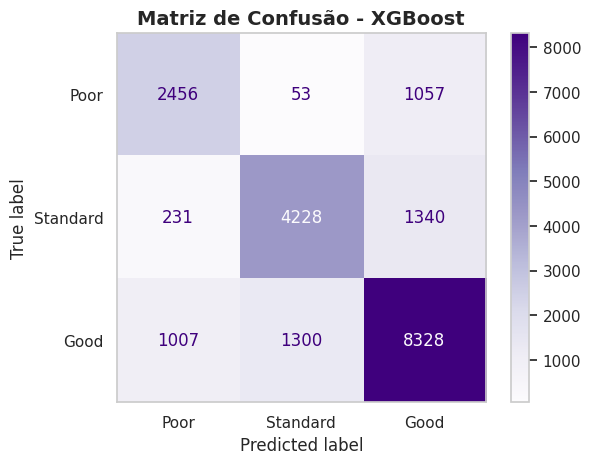

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# relatório de Métricas do XGBoost
print("--- RELATÓRIO DE PERFORMANCE (XGBOOST) ---")
print(classification_report(y_teste, predicoes_xgb, target_names=['Poor', 'Standard', 'Good']))

# gráfico da Matriz de Confusão do XGBoost
cm_xgb = confusion_matrix(y_teste, predicoes_xgb)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Poor', 'Standard', 'Good'])
disp_xgb.plot(cmap='Purples', values_format='d') # Usando a cor roxa para diferenciar da Random Forest

plt.title('Matriz de Confusão - XGBoost', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

##Avaliação dos Modelos

/tmp/ipykernel_3411/750829460.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancia.head(10), x='Importancia', y='Variavel', palette='mako')


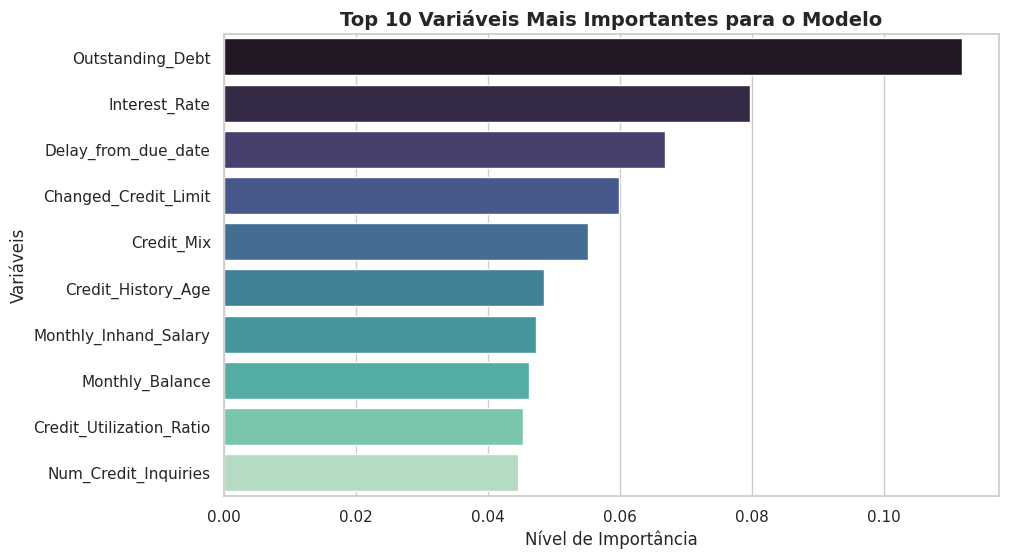

In [31]:
# pega as importâncias calculadas pelo modelo Random Forest
importancias = modelo_rf.feature_importances_

# cria uma tabela associando o nome da coluna com a sua importância
df_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# desenha o gráfico das 10 variáveis mais importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia.head(10), x='Importancia', y='Variavel', palette='mako')

plt.title('Top 10 Variáveis Mais Importantes para o Modelo', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Importância')
plt.ylabel('Variáveis')
plt.show()

### Avaliação dos Modelos e Impacto de Negócio

Após avaliar os dois modelos de Machine Learning na base de testes (20.000 clientes), o modelo **Random Forest** foi o escolhido para o pipeline da Data Girls Finance pelos seguintes motivos:

1. **Maior Assertividade Geral (Acurácia):** O Random Forest obteve uma acurácia de **79%**, superando os 75% obtidos pelo XGBoost.
2. **Proteção Contra Inadimplência (Falsos Positivos):** Na classe de maior risco comercial (*Poor*), o Random Forest apresentou maior Precisão (74% vs 66%) e maior Recall (72% vs 69%).

#### **Análise de Impacto Financeiro dos Erros:**

* **Falso Positivo de Risco (Prever "Good" quando o cliente é "Poor"):** O modelo Random Forest deixa passar apenas 28% de clientes inadimplentes (Recall de 72%), enquanto o XGBoost deixa passar 31%. Adotar o Random Forest significa mitigar o volume de calotes diretos na nossa carteira de crédito, protegendo o caixa da fintech.
* **Falso Negativo (Negar crédito a quem é "Good"):** O Random Forest manteve uma excelente performance para os bons clientes (*Good*), com 80% de Recall e 81% de Precisão. Isso garante que a fintech não perca receita recusando bons pagadores por engano, mantendo a experiência do cliente fluida.

#### **Importância das Variáveis no Negócio:**
Complementando a análise com o gráfico de relevância de recursos, identificamos que o comportamento histórico (como dias de atraso e histórico de pagamentos) pesa muito mais para a decisão final do que a renda declarada isolada. Portanto, o Random Forest conseguiu capturar melhor essas relações não-lineares para tomar decisões de crédito mais seguras.